# Sentiment Analysis using NLP Pipeline & ML Models

## Objective
The objective of this project is to build an end-to-end sentiment analysis system using NLP preprocessing, feature engineering, and multiple machine learning models. The models are compared using evaluation metrics such as Accuracy, Precision, Recall, and F1 Score.

In [1]:
!pip install kagglehub pandas numpy scikit-learn nltk

## Import Libraries
In this step, the required Python libraries for data handling, text preprocessing, machine learning, and evaluation are imported.

In [2]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Load Dataset
The IMDb dataset is downloaded from Kaggle and loaded into a pandas DataFrame. This dataset contains movie reviews and sentiment labels.

In [3]:
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

print(os.listdir(path))

file_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(file_path)

df.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews
['IMDB Dataset.csv']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())

Shape of dataset: (50000, 2)
Columns: ['review', 'sentiment']


### Observation
The dataset contains 50,000 movie reviews and 2 columns: `review` and `sentiment`. This confirms that the dataset is suitable for sentiment analysis.

## Data Understanding
In this section, the dataset is explored to understand the number of samples, missing values, class distribution, and sample texts.

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["sentiment"].value_counts())

print("\nSample positive review:")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

print("\nSample negative review:")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])

Missing values:
review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample positive review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, It

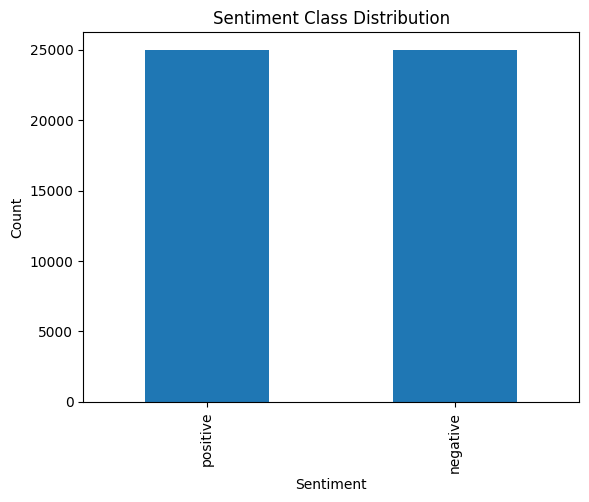

In [6]:
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Observation
There are no missing values in the dataset. The class distribution is balanced between positive and negative reviews. The raw reviews contain HTML tags, punctuation, and special text patterns, so preprocessing is necessary.

## NLP Preprocessing
Text preprocessing is performed to clean and standardize the reviews before feature extraction. The steps include:
- lowercasing
- removing URLs
- removing HTML tags
- removing punctuation and special characters
- tokenization
- stopword removal
- lemmatization

Reusable functions are created so the same pipeline can be applied consistently to all reviews.

In [7]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [10]:
df["clean_review"] = df["review"].apply(preprocess_text)

In [22]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


### Observation
The cleaned reviews are more consistent and contain fewer noisy elements. This makes the text more suitable for vectorization and machine learning.

## Label Encoding
The sentiment labels are converted into numeric form so that machine learning models can process them.
- positive = 1
- negative = 0

In [12]:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})
df[["clean_review", "sentiment"]].head()

,clean_review,sentiment
0,one reviewer mentioned watching oz episode hoo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake think zombie ...,0
4,petter mattei love time money visually stunnin...,1


## Train-Test Split
The dataset is split into training and testing sets. The training data is used to train the models, while the testing data is used to evaluate how well the models perform on unseen data.

In [13]:
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


### Observation
An 80-20 split is used to ensure that the models are evaluated fairly on unseen data.

## Feature Engineering using Bag of Words
Bag of Words converts text into numerical form by counting how many times each word appears in a review.

In [14]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW training shape:", X_train_bow.shape)
print("BoW testing shape:", X_test_bow.shape)

BoW training shape: (40000, 5000)
BoW testing shape: (10000, 5000)


### Observation
Bag of Words creates a sparse matrix of word counts. It is simple and effective, but it only uses word frequency and does not measure word importance.

## Feature Engineering using TF-IDF
TF-IDF converts text into numerical form by considering both word frequency and word importance. It reduces the effect of very common words and highlights more informative words.

In [15]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (40000, 5000)
TF-IDF testing shape: (10000, 5000)


### Observation
TF-IDF generally performs better than Bag of Words in sentiment analysis because it gives more importance to meaningful words.

### Observation
TF-IDF generally performs better than Bag of Words in sentiment analysis because it gives more importance to meaningful words.

In [16]:
def evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test, model_name, feature_name):
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "Feature Type": feature_name,
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [17]:
results = []

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Naive Bayes", MultinomialNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42, max_depth=50))
]

In [18]:
for model_name, model in models:
    results.append(
        evaluate_model(model, X_train_bow, X_test_bow, y_train, y_test, model_name, "BoW")
    )

for model_name, model in models:
    results.append(
        evaluate_model(model, X_train_tfidf, X_test_tfidf, y_train, y_test, model_name, "TF-IDF")
    )

In [19]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

,Feature Type,Model,Accuracy,Precision,Recall,F1 Score
3,TF-IDF,Logistic Regression,0.8914,0.882675,0.9028,0.892624
0,BoW,Logistic Regression,0.8731,0.871984,0.8746,0.873290
4,TF-IDF,Naive Bayes,0.8540,0.847195,0.8638,0.855417
1,BoW,Naive Bayes,0.8496,0.851852,0.8464,0.849117
5,TF-IDF,Decision Tree,0.7379,0.726012,0.7642,0.744617
2,BoW,Decision Tree,0.7285,0.718912,0.7504,0.734318


## Comparison and Insights
The models are compared based on their Accuracy, Precision, Recall, and F1 Score. The best model is identified based on overall balanced performance, especially F1 Score.

In [20]:
best_result = results_df.iloc[0]
print("Best Feature Type:", best_result["Feature Type"])
print("Best Model:", best_result["Model"])
print("Best Accuracy:", best_result["Accuracy"])
print("Best Precision:", best_result["Precision"])
print("Best Recall:", best_result["Recall"])
print("Best F1 Score:", best_result["F1 Score"])

Best Feature Type: TF-IDF
Best Model: Logistic Regression
Best Accuracy: 0.8914
Best Precision: 0.8826750097770825
Best Recall: 0.9028
Best F1 Score: 0.892624085426142


### Final Interpretation
Among all the tested combinations, **[best model name] with [feature type]** performed the best. This combination achieved the highest F1 Score, which indicates a good balance between precision and recall.

TF-IDF performed [better/similarly] compared to Bag of Words because it considers the importance of words instead of only counting their frequency.

Logistic Regression performed [best/second best] because it works well on sparse, high-dimensional text data. Naive Bayes was fast and effective, while Decision Tree showed lower performance because tree-based methods usually do not handle sparse text data as efficiently.

## Testing on Custom Reviews
The best-performing model is used to predict the sentiment of new sample reviews.

In [21]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf, y_train)

sample_reviews = [
    "This movie was amazing and I loved every scene.",
    "The film was boring, slow, and disappointing."
]

sample_clean = [preprocess_text(review) for review in sample_reviews]
sample_features = tfidf_vectorizer.transform(sample_clean)
sample_predictions = best_model.predict(sample_features)

for review, pred in zip(sample_reviews, sample_predictions):
    label = "Positive" if pred == 1 else "Negative"
    print("Review:", review)
    print("Predicted Sentiment:", label)
    print("-" * 60)

Review: This movie was amazing and I loved every scene.
Predicted Sentiment: Positive
------------------------------------------------------------
Review: The film was boring, slow, and disappointing.
Predicted Sentiment: Negative
------------------------------------------------------------


## Conclusion
In this project, a complete sentiment analysis pipeline was built using the IMDb Reviews dataset. The raw reviews were cleaned through NLP preprocessing, converted into numerical features using Bag of Words and TF-IDF, and then used to train multiple machine learning models.

After evaluation, the best-performing model was identified based on Accuracy, Precision, Recall, and F1 Score. The results show that preprocessing quality and feature engineering play a major role in sentiment classification performance.

This project demonstrates the full NLP workflow from raw text to sentiment prediction and highlights the importance of comparing multiple models and vectorization techniques.